# General Assay Results Plotting

This notebook generates high-resolution line-and-scatter plots for biochemical assays. 

### Features:
- **Smooth Curves**: Uses 4-Parameter Logistic (4PL) regression or Spline interpolation for smooth data lines.
- **Dotted IC50 Reference**: Vertical lines for IC50 are dotted for clarity.
- **Automated Layout Detection**
- **Summary Panel**: Explicit display of calculated IC50 values.
- **Robust Legend**: Positioned outside to avoid overlap.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import os
from scipy.optimize import curve_fit
from scipy.interpolate import make_interp_spline

%matplotlib inline

### 1. Load and Clean Data

In [25]:
csv_path = 'HRBC Job.csv'  

try:
    try:
        df = pd.read_csv(csv_path)
    except UnicodeDecodeError:
        df = pd.read_csv(csv_path, encoding='latin-1')
    
    df.columns = df.columns.str.strip()
    df = df.dropna(how='all').dropna(axis=1, how='all')
    
    print(f"Successfully loaded: {csv_path}")
    display(df.head())
    
except FileNotFoundError:
    print(f"Error: '{csv_path}' not found.")

Successfully loaded: HRBC Job.csv


,Compound,125 µM (%),250 µM (%),500 µM (%)
0,FA,12.29,17.52,42.03
1,FA-1,12.44,17.53,28.94
2,FA-2,10.17,14.52,30.28
3,FA-3,0.07,10.05,16.84
4,FA-4,8.07,12.99,19.58


### 2. IC50 Modeling

In [26]:
def logistic4(x, a, b, c, d):
    return d + (a - d) / (1 + (x / c)**b)

def calculate_ic50(x_data, y_data):
    try:
        p0 = [min(y_data), 1, np.median(x_data), max(y_data)]
        popt, _ = curve_fit(logistic4, x_data, y_data, p0=p0, maxfev=20000)
        a, b, c, d = popt
        if (a-d) != 0 and (50-d)/(a-d) > 0:
            val = (a - d) / (50 - d) - 1
            if val > 0:
                return c * (val**(1/b)), popt
        return None, None
    except:
        return None, None

### 3. Visualization

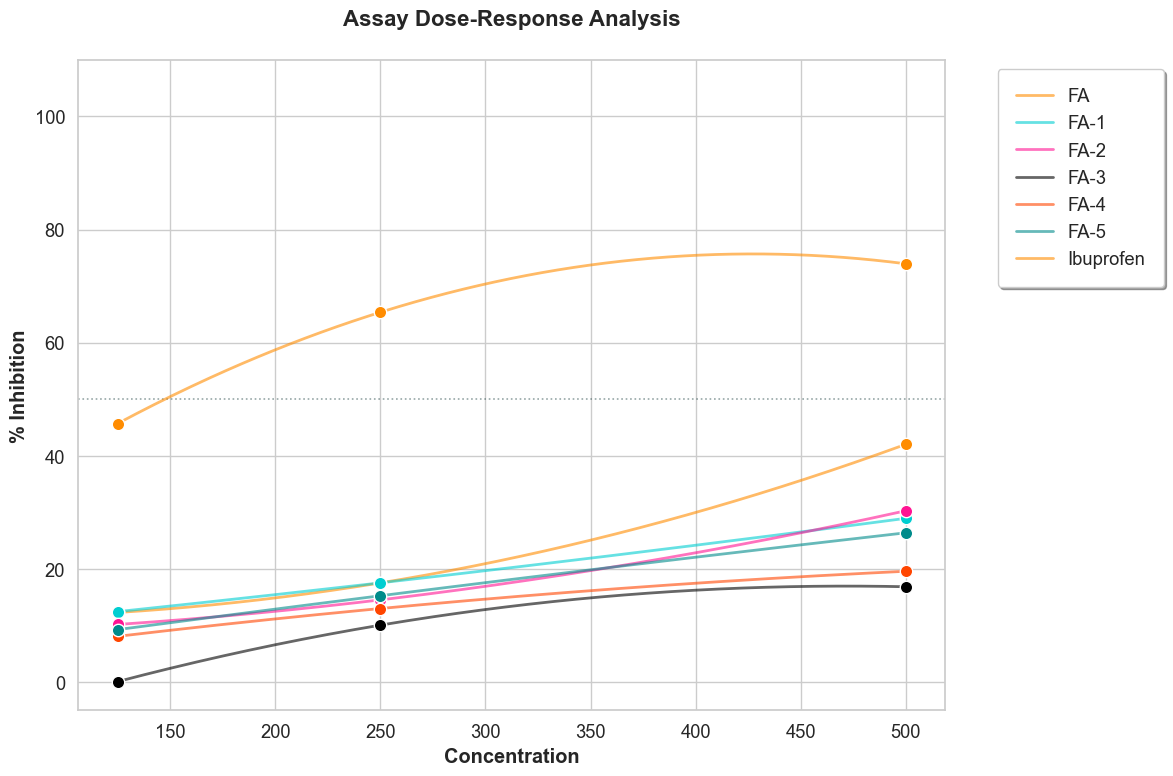

In [27]:
try:
    # Custom palette avoiding restricted colors
    custom_colors = ['#FF8C00', '#00CED1', '#FF1493', '#000000', '#FF4500', '#008B8B']
    sns.set_theme(style="whitegrid", font_scale=1.2)
    fig, ax = plt.subplots(figsize=(12, 8))

    ic50_results = []
    
    if 'Compound' in df.columns:
        value_cols = [c for c in df.columns if c != 'Compound']
        x_numeric = np.array([float(re.search(r'(\d+)', c).group(1)) if re.search(r'(\d+)', c) else c for c in value_cols])
        x_smooth = np.linspace(min(x_numeric), max(x_numeric), 300)
        
        for i, (idx, row) in enumerate(df.iterrows()):
            name = str(row['Compound']).strip()
            if not name or name == 'nan': continue
            y_values = row[value_cols].values.astype(float)
            color = custom_colors[i % len(custom_colors)]
            
            ic50, popt = calculate_ic50(x_numeric, y_values)
            ax.scatter(x_numeric, y_values, color=color, s=80, edgecolors='white', zorder=3)
            
            # RENDERING CURVES
            if popt is not None:
                ax.plot(x_smooth, logistic4(x_smooth, *popt), color=color, label=name, linewidth=2.5, linestyle='-', zorder=2)
                if ic50 and min(x_numeric) <= ic50 <= max(x_numeric): ic50_results.append((name, ic50, color))
            else:
                # Spline fallback for curvy lines
                try:
                    spline = make_interp_spline(x_numeric, y_values, k=2)
                    ax.plot(x_smooth, spline(x_smooth), color=color, label=name, linewidth=2, linestyle='-', alpha=0.6)
                except:
                    ax.plot(x_numeric, y_values, color=color, label=name, linewidth=2, linestyle='-', alpha=0.6)
                    
        plt.xlabel('Concentration', fontweight='bold')
        
    elif 'Mass (ug)' in df.columns:
        col_x = 'Mass (ug)'
        x_data = df[col_x].values
        x_smooth = np.linspace(min(x_data), max(x_data), 300)
        mapping = {'Std Inhibition%': 'Standard', 'RCE inhibition%': 'Sample RCE', 'CAE %inhibition': 'Sample CAE'}
        
        for i, (col, label) in enumerate(mapping.items()):
            if col in df.columns:
                y_data = df[col].values
                color = custom_colors[i % len(custom_colors)]
                ic50, popt = calculate_ic50(x_data, y_data)
                ax.scatter(x_data, y_data, color=color, s=80, edgecolors='white', zorder=3)
                
                if popt is not None:
                    ax.plot(x_smooth, logistic4(x_smooth, *popt), color=color, label=label, linewidth=2.5, linestyle='-', zorder=2)
                    if ic50 and min(x_data) <= ic50 <= max(x_data): ic50_results.append((label, ic50, color))
                else:
                    try:
                        spline = make_interp_spline(x_data, y_data, k=2)
                        ax.plot(x_smooth, spline(x_smooth), color=color, label=label, linewidth=2, linestyle='-', alpha=0.6)
                    except:
                        ax.plot(x_data, y_data, color=color, label=label, linewidth=2, linestyle='-', alpha=0.6)
        plt.xlabel('Concentration (µg)', fontweight='bold')

    # DOTTED REFERENCE LINES
    ax.axhline(50, color='#2F4F4F', linestyle=':', linewidth=1.2, alpha=0.5, zorder=1)
    for name, ic50, color in ic50_results:
        ax.axvline(ic50, ymin=0, ymax=0.5, color=color, linestyle=':', linewidth=1.5, alpha=0.7)

    # Summary Panel
    if ic50_results:
        summary = "IC50 Values:\n" + "\n".join([f"{n}: {ic:.2f}" for n, ic, c in ic50_results])
        ax.text(0.98, 0.02, summary, transform=ax.transAxes, fontsize=10, fontweight='bold', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), 
                verticalalignment='bottom', horizontalalignment='right', family='monospace')

    plt.ylabel('% Inhibition', fontweight='bold')
    plt.title('Assay Dose-Response Analysis', fontweight='bold', pad=25, fontsize=16)
    
    # Legend outside to the right
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True, borderpad=1)
    
    plt.ylim(-5, 110)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")